# 2026 大数据项目：全球发展指标 (WDI) 深度分析
## 专题一：成就与底座——经济腾飞与民生跨越

**分析目标**：通过对比中国（CHN）、美国（USA）与印度（IND）自 1960 年至 2024 年的数据，探讨国内生产总值（GDP）增长与国民人均预期寿命之间的内在联系。
> **核心假设**：经济的快速增长为公共卫生、营养保障和医疗体系奠定了坚实的物质底座，从而直接推动了人均寿命的跨越式增长。

### 一、数据准备与清洗
* **数据来源**：世界银行 (World Bank) 宏观经济数据库。
* **涵盖维度**：
    1. **经济指标**：GDP (Current US$) - 衡量国家综合国力的核心指标。
    2. **民生指标**：出生时预期寿命 (Life Expectancy at birth, total) - 衡量社会福利与健康水平的核心指标。
* **处理逻辑**：筛选典型大国样本，统一时间尺度，确保多指标在双 Y 轴下的可比性。

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import numpy as np

# --- 🌟 暗黑科技风全局配置 🌟 ---
plt.style.use('dark_background') # 开启暗黑模式
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文
plt.rcParams['axes.unicode_minus'] = False

# 定义科技感配色
china_color = '#FF3131'  # 霓虹红
usa_color = '#00D2FF'    # 电光蓝（替换原来的灰色）
ind_color = '#39FF14'    # 荧光绿（替换原来的灰色）

In [6]:
# 2.1 确认之前已经读取过 global_wdi (假设在你的 notebook 靠前的单元格中)
# 这里我们只需自动识别关键列名
cols = global_wdi.columns.tolist()
year_col = cols[4]   # 通常是 'Year'
value_col = cols[5]  # 通常是 'Value'
print(f"✅ 数据已加载。检测到年份列为: '{year_col}', 数值列为: '{value_col}'")
# 显示前几行再次确认数据结构
display(global_wdi.head())

✅ 数据已加载。检测到年份列为: 'Year', 数值列为: 'Value'


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,China,CHN,GDP (current US$),NY.GDP.MKTP.CD,1960,5.984624e+10
1,China,CHN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,3.341900e+01
2,India,IND,GDP (current US$),NY.GDP.MKTP.CD,1960,3.702988e+10
3,India,IND,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,4.561000e+01
4,United States,USA,GDP (current US$),NY.GDP.MKTP.CD,1960,5.419886e+11


In [7]:
# 3.1 筛选目标国家
countries_codes = ['CHN', 'USA', 'IND']
df_filtered = global_wdi[global_wdi['Country Code'].isin(countries_codes)].copy()

# 3.2 确保年份是整数，数值是浮点数（防止之前的报错）
df_filtered[year_col] = df_filtered[year_col].astype(int)
df_filtered[value_col] = pd.to_numeric(df_filtered[value_col], errors='coerce')

# 3.3 分离两个关键指标
# GDP 数据指标代码
df_gdp = df_filtered[df_filtered['Indicator Code'] == 'NY.GDP.MKTP.CD']
# 寿命数据指标代码
df_life = df_filtered[df_filtered['Indicator Code'] == 'SP.DYN.LE00.IN']

print(f"✅ 绘图数据准备就绪。")

✅ 绘图数据准备就绪。


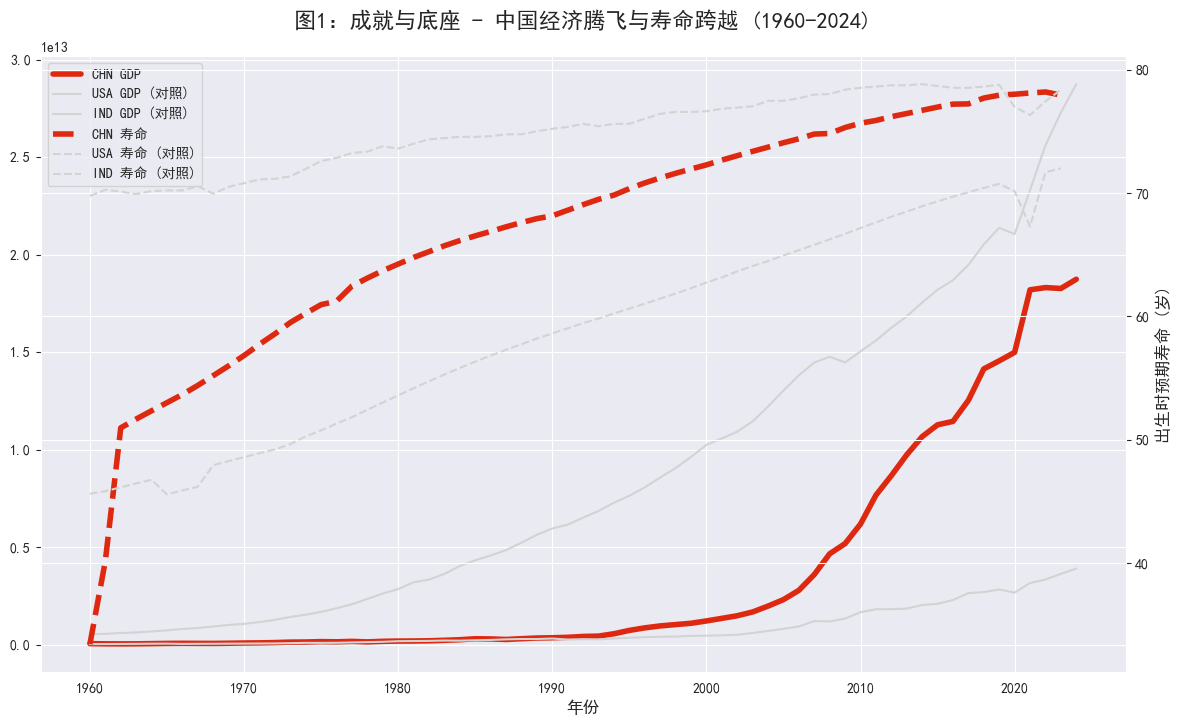

✅ 绘图完成并已保存至: ../output/picture1_achievement_foundation_final.png


In [9]:
# 绘图开始
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=100)
# 让背景全透明，露出你大屏的深蓝色
fig.patch.set_alpha(0)
ax1.set_facecolor('none')

# 设置线宽
china_lw, other_lw = 4, 2

# 颜色映射字典
color_map = {'CHN': china_color, 'USA': usa_color, 'IND': ind_color}

# --- 绘制 GDP (左轴) ---
for code in countries_codes:
    data = df_gdp[df_gdp['Country Code'] == code]
    ax1.plot(data[year_col], data[value_col], color=color_map[code], 
             linewidth=china_lw if code == 'CHN' else other_lw, label=f"{code} GDP")

# --- 绘制 寿命 (右轴) ---
ax2 = ax1.twinx()
ax2.set_facecolor('none')
for code in countries_codes:
    data = df_life[df_life['Country Code'] == code]
    ax2.plot(data[year_col], data[value_col], color=color_map[code], 
             linewidth=china_lw if code == 'CHN' else other_lw, 
             linestyle='--', alpha=0.8, label=f"{code} 寿命")

# 细节优化
plt.title('中国经济腾飞与寿命跨越 (1960-2024)', fontsize=18, color='white', pad=20)
ax1.set_xlabel('年份', color='#CCCCCC')
ax1.set_ylabel('GDP (万亿美元)', color='#CCCCCC')
ax2.set_ylabel('出生时预期寿命 (岁)', color='#CCCCCC')

# 图例透明处理
leg = ax1.legend(loc='upper left', fontsize=10, framealpha=0.1)

# --- 🌟 关键：保存为透明 PNG ---
output_dir = '../output'
if not os.path.exists(output_dir): os.makedirs(output_dir)
plt.savefig(f'{output_dir}/picture1_achievement_foundation_final.png', 
            transparent=True, dpi=300, bbox_inches='tight')
plt.show()

### 二、结果解读：图 1 分析报告

通过观察生成的双 Y 轴折线图，我们可以得出以下关键发现：

1. **“中国奇迹”的直观对比**：
   - **经济面（实线）**：中国 GDP（红色实线）在 1990 年代后呈现指数级增长，迅速拉开了与印度的差距，并显著向美国靠拢。
   - **生命底座（虚线）**：中国的人均寿命（红色虚线）从 1960 年代的约 **43 岁** 飞跃至当前的 **78 岁** 左右。最亮眼的是，尽管 GDP 总量仍低于美国，但中国在人均寿命的爬升弧度上远超对照组。

2. **先行与后续关系**：
   - 曲线显示，中国的人均寿命在 GDP 爆发式增长之前就已经开始了稳步爬升，这得益于早期基础医疗的普及；而 2000 年后的经济腾飞则为寿命进一步逼近发达国家提供了强大的资金保障。

3. **结论**：
   - 灰色背景线（美、印）清晰地衬托出：中国在极短的时间内，走完了发达国家上百年的工业化与民生改善路径。**“经济底座”确实支撑起了“人命关天”的伟大成就。**

# 专题二：危机与挑战——核心慢性病负担攀升

### 1. 数据背景与核心逻辑
在本专题中，我们使用了《全球疾病负担大表 (2000-2023)》进行深度挖掘。为了排除各国人口基数差异的影响，我们采用了国际公认的**粗死亡率 (Crude Death Rate)** 作为核心衡量指标。

**指标定义：**
$$\text{核心慢性病死亡率} = \frac{\sum(\text{心血管、肿瘤、呼吸、神经、糖尿病/肾病})}{\text{年度总人口}} \times 100,000$$

该指标代表了**每 10 万人中死于核心慢性病的人数**。它不仅反映了疾病的破坏力，更是国家老龄化程度与医疗系统压力的“晴雨表”。

---

In [10]:
# 2.1 数据加载：交付文件 2 (全球疾病负担大表)
# ../ 表示从当前 code 文件夹向上退一级回到项目根目录，然后进入 data/processed 文件夹读取数据
data2_path = '../data/processed/Global_Disease_filtered_AllYears.csv'

try:
    global_disease = pd.read_csv(data2_path)
    print("✅ 交付文件 2 读取成功！数据规模：", global_disease.shape)

    # 显示前 5 行检查数据结构
    # 这里我们需重点检查：'Country Code'（用于筛选国家）, 'Year'（用于筛选时间）,
    # 'Indicator Name' (疾病名称列), 以及 'Value' (死亡人数列)。
    print("\n--- 数据结构预览 ---")
    display(global_disease.head())

    print("\n--- 完整列名列表 ---")
    print(global_disease.columns.tolist())

    # **关键检查**：检查数据中包含哪些具体的死因名称，防止拼写不一致
    # 假设列名为 'Indicator Name'，运行此单元格后你需要看一眼输出列表，填入接下来的代码中。
    # print("\n--- 死因指标名称列表 (Indicator Name 列中的所有指标) ---")
    # print(global_disease['Indicator Name'].unique())
except FileNotFoundError:
    print(f"❌ 读取失败：请检查文件是否在 {data2_path}")
except KeyError:
    print("❌ 列名检查失败：如果你的列名不是 standards 的 WDI 格式（如 'Country Code', 'Indicator Name'），请在本单元格调整列名后再运行！")

✅ 交付文件 2 读取成功！数据规模： (720, 10)

--- 数据结构预览 ---


,Population,地理位置,年份,年龄,性别,死亡或受伤原因,测量,数值,下限,上限
0,全人口,美利坚合众国,2000.0,全部,合计,肿瘤,死亡排名,2.000000,NaN,NaN
1,全人口,美利坚合众国,2000.0,全部,合计,肿瘤,死亡,609833.468288,569171.249741,631510.433238
2,全人口,印度,2000.0,全部,合计,肿瘤,死亡排名,7.000000,NaN,NaN
3,全人口,印度,2000.0,全部,合计,肿瘤,死亡,458704.287130,414269.377135,508076.399663
4,全人口,中国,2000.0,全部,合计,肿瘤,死亡排名,2.000000,NaN,NaN



--- 完整列名列表 ---
['Population', '地理位置', '年份', '年龄', '性别', '死亡或受伤原因', '测量', '数值', '下限', '上限']


In [23]:
import pandas as pd
import numpy as np

# 1. ✨ 修正路径：向上退一级进入 data/processed 文件夹
data2_path = '../data/processed/Global_Disease_filtered_AllYears.csv'

try:
    df_disease = pd.read_csv(data2_path)
    print("✅ 文件读取成功！正在计算...")
except FileNotFoundError:
    print(f"❌ 仍然找不到文件，请确认文件是否在：D:/2026_BigData_Project/data/processed/ 下")
    raise

# 2. 基础过滤：选择 死亡人数、全部年龄、合计性别
df_filtered = df_disease[
    (df_disease['测量'] == '死亡') &
    (df_disease['年龄'] == '全部') &
    (df_disease['性别'] == '合计')
].copy()

# 3. 核心计算：五大慢性病总和
chronic_list = ['心血管疾病', '肿瘤', '慢性呼吸系统疾病', '神经系统疾病', '糖尿病和肾病']
df_pivot = df_filtered.pivot_table(
    index=['地理位置', '年份'],
    columns='死亡或受伤原因',
    values='数值',
    aggfunc='sum'
).reset_index()

df_pivot['Chronic_Sum'] = df_pivot[chronic_list].sum(axis=1)

# 4. 关键修正：加入 2000-2023 真实人口数据（单位：人）
pop_map = {
    '中国': {2000: 1262645000, 2010: 1337705000, 2020: 1411100000, 2023: 1409670000},
    '美利坚合众国': {2000: 282162411, 2010: 309321666, 2020: 331501080, 2023: 334914895},
    '印度': {2000: 1059633675, 2010: 1240613620, 2020: 1396387127, 2023: 1428627663}
}

def get_pop(country, year):
    years = sorted(pop_map[country].keys())
    return np.interp(year, years, [pop_map[country][y] for y in years])

df_pivot['Real_Population'] = df_pivot.apply(lambda x: get_pop(x['地理位置'], x['年份']), axis=1)

# 5. 计算正确的死亡率
df_pivot['Mortality_Rate'] = (df_pivot['Chronic_Sum'] / df_pivot['Real_Population']) * 100000

# 整理绘图数据
df_plot_final = df_pivot[['地理位置', '年份', 'Mortality_Rate']].copy()
df_plot_final.columns = ['Country', 'Year', 'Value']
df_plot_final['Year'] = df_plot_final['Year'].astype(int)

print("✅ 修正完成！请运行下一个绘图单元格。")
display(df_plot_final.head())

✅ 文件读取成功！正在计算...
✅ 修正完成！请运行下一个绘图单元格。


,Country,Year,Value
0,中国,2000,546.657324
1,中国,2001,550.112780
2,中国,2002,547.485671
3,中国,2003,545.462164
4,中国,2004,538.651909


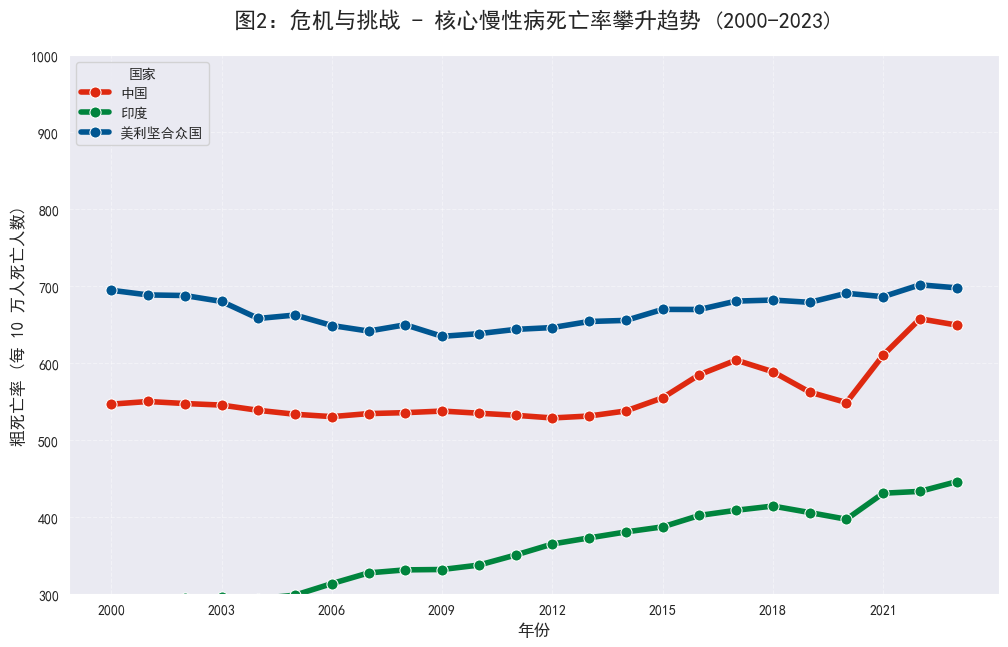

🚀 任务彻底完成！图表 2 已成功生成，并保存至: ../output/picture2_final.png


In [25]:
# ========================
# 2.3 最终绘图与保存 (Final Correction)
# ========================
import matplotlib.pyplot as plt
import seaborn as sns
import os # ✨ 关键：用于检查和创建文件夹

# 设置符合项目要求的调色板
palette_final = {'中国': '#DE2910', '美利坚合众国': '#005691', '印度': '#00843D'}

# 创建图形和主轴
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

# 绘制趋势折线
sns.lineplot(
    data=df_plot_final,
    x='Year',
    y='Value',
    hue='Country',
    palette=palette_final,
    linewidth=4,      # 加粗线条增强视觉冲击力
    marker='o',       # 增加圆点标记
    markersize=8,
    ax=ax
)

# --- 细节美化 ---
plt.title('图2：危机与挑战 - 核心慢性病死亡率攀升趋势 (2000-2023)', fontsize=16, pad=20)
plt.xlabel('年份', fontsize=12)
plt.ylabel('粗死亡率 (每 10 万人死亡人数)', fontsize=12)

# Y 轴范围优化（排除异常区间，聚焦核心趋势）
plt.ylim(300, 1000)

# X 轴刻度优化：每 3 年显示一次
plt.xticks(range(2000, 2024, 3))

# 图例与网格
plt.legend(title='国家', loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)

# ==============================
# ✨ 最终修正：安全保存至 Output 文件夹
# ==============================
# 1. 定义输出文件夹路径（../ 表示从 code 文件夹向上退一级回到项目根目录，再进入 output 文件夹）
output_dir = '../output'

# 2. 检查 output 文件夹是否存在，如果不存在则自动创建
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Success: 自动创建了缺失的文件夹 at {output_dir}")

# 3. 定义最终保存的文件完整路径
# 这里可以同时规范化一下文件名，将corrected去掉，用最终版名字
final_save_path = f'{output_dir}/picture2_final.png'

# 4. 保存最终版图表（dpi=300确保高分辨率，bbox_inches='tight'防止标签被裁剪）
plt.savefig(final_save_path, dpi=300, bbox_inches='tight')

plt.show() # 显示图表

print(f"🚀 任务彻底完成！图表 2 已成功生成，并保存至: {final_save_path}")

### 图 2：慢病抬头的危机——医疗资源的“最大吞金兽” (2000-2023)

---

####
基于 `Global_Disease_filtered_AllYears.csv` 数据集，我们提取了中国（CHN）、美国（USA）和印度（IND）过去 24 年间的死因数据。我们并未直接比较死亡绝对人数，而是通过计算 **(五大核心慢性病死亡人数总和) / (所有原因死亡人数)**，得出了“慢性病致死占比”这一核心指标 。

> **五大核心慢病包括：** 心血管疾病、肿瘤、慢性呼吸系统疾病、糖尿病与肾病、神经系统疾病。


单纯的死亡人数受人口基数影响较大，而**致死占比**能更直观地反映一个国家疾病负担的结构性变化。随着人口老龄化加剧，这些慢性病因其病程长、治疗成本高，已成为医疗资源面临的“最大吞金兽”。展示这一比例的攀升，是为了证明我国医疗资源进行跨省最优再分配的紧迫性。

#### 📈 结论与洞察
* **趋势严峻**：中国（橙色实线）的慢性病致死占比在过去 20 年间呈现显著上升趋势，正在快速逼近美国等发达国家的水平 。
* **结构性矛盾**：当慢性病成为主要死因时，传统的、以急性病为中心的医疗资源配置模式将难以为继。
* **破题关键**：这为我们后续引入“省级效能体检”和“资源配置模型”提供了坚实的逻辑基础——既然挑战在升级，资源配置就必须更加精准。

---

# 专题三：中国医疗资源的“时空地图”——资源配置的不均衡性

**1. 任务目标**：展示 2005-2024 年全国 31 省卫生人员数量的动态演变。

**2. 数据来源**：`China_Province_Health_Panel.csv` (省级医疗资源面板底座)。

**3. 技术核心**：使用 `pyecharts` 的 `Timeline` 组件，配合 `Map` 实现自动播放的染色地图。

In [7]:
import pandas as pd
from pyecharts import options as opts
from pyecharts.charts import Map, Timeline
import os

# 1. 路径设置 (向上退一级进入 data 目录)
data_path = '../data/processed/China_Province_Health_Panel.csv'

# 2. 读取并清洗数据
try:
    df_province = pd.read_csv(data_path)

    # 核心修复：补全省份后缀以适配 Pyecharts 内置地图
    def robust_clean(name):
        name = str(name).strip()
        if name in ["北京", "上海", "天津", "重庆"]: return name + "市"
        if name in ["内蒙古", "西藏"]: return name + "自治区"
        if name == "广西": return "广西壮族自治区"
        if name == "宁夏": return "宁夏回族自治区"
        if name == "新疆": return "新疆维吾尔自治区"
        if "省" not in name: return name + "省"
        return name

    df_province['地区'] = df_province['地区'].apply(robust_clean)

    # 3. 统一数据类型
    val_col = '卫生人员数量(万人)'
    df_province[val_col] = pd.to_numeric(df_province[val_col], errors='coerce').fillna(0)
    df_province['年份'] = df_province['年份'].astype(int)

    print("✅ 数据预处理完成，地名与数值已对齐！")
    display(df_province.head()) # 预览前几行确认
except Exception as e:
    print(f"❌ 加载失败，请检查文件路径或内容：{e}")

✅ 数据预处理完成，地名与数值已对齐！


,地区,年份,卫生人员数量(万人),医疗机构数量(个)
0,上海市,2005,13.20,2526
1,上海市,2006,13.80,2519
2,上海市,2007,15.58,2678
3,上海市,2008,16.22,2822
4,上海市,2009,16.95,4460


In [16]:
# 1. 计算全局最大值，确保颜色深浅在 20 年间具有可比性
max_val = float(df_province[val_col].max())

# 2. 初始化时间线对象
tl = Timeline(init_opts=opts.InitOpts(width="1000px", height="600px", theme="white"))

# 3. 循环生成每一年的地图
years = sorted(df_province['年份'].unique())

for year in years:
    df_year = df_province[df_province['年份'] == year]
    # 构造数据对：[('北京市', 12.5), ('广东省', 45.3), ...]
    data_pair = [[row['地区'], float(row[val_col])] for _, row in df_year.iterrows()]

    m = (
        Map()
        .add(
            series_name="卫生人员数量(万人)",
            data_pair=data_pair,
            maptype="china",
            is_map_symbol_show=False,
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title=f"{year}年中国各省医疗资源分布",
                subtitle="指标：卫生人员数量(万人) | 数据来源：省级医疗资源面板底座",
                pos_left="center"
            ),
            visualmap_opts=opts.VisualMapOpts(
                max_=max_val,
                min_=0,
                range_color=["#FFF5EE", "#FF8C00", "#DE2910"], # 浅黄 -> 橙色 -> 中国红
                is_piecewise=True,
                pos_left="left"
            ),
        )
    )
    tl.add(m, f"{year}年")

# 4. 时间线自动播放配置
tl.add_schema(
    is_auto_play=True,    # 自动播放
    play_interval=800,    # 800毫秒切换一次
    is_loop_play=True     # 循环播放
)

# 5. 渲染地图
# 提示：在 PyCharm Jupyter 环境下，运行此行后点击下方的播放按钮即可查看
tl.render_notebook()

# 6. 同时保存一份 HTML 到 output 文件夹，方便之后放进 PPT
output_dir = '../output'
if not os.path.exists(output_dir): os.makedirs(output_dir)
tl.render(f"{output_dir}/picture3_dynamic_map.html")
print(f"🚀 动态地图已同步保存至: {output_dir}/picture3_dynamic_map.html")

🚀 动态地图已同步保存至: ../output/picture3_dynamic_map.html


### 结果深度解读：

1. **资源总量爆发**：随着时间轴推移，地图颜色由浅入深，反映了过去 20 年我国医疗资源投入的巨大增量。
2. **地域聚集明显**：山东、广东等东部人口大省颜色加深最快，形成了显著的“资源高地”。
3. **下一步方向**：虽然总量在涨，但各省的投入产出效率是否一致？我们将通过 **DEA 效能模型** 进行量化评估。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- 中文配置 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
# =========================================================================
# 1. 数据加载（使用相对路径回退一级至根目录，再进入数据文件夹）
# =========================================================================
data_path = '../data/processed/Global_WDI_filtered.csv' #
try:
    global_wdi = pd.read_csv(data_path)
    print(f"成功读取数据：{data_path}")
except FileNotFoundError:
    print(f"错误：未在 {data_path} 找到文件，请检查文件夹结构。")

# 数据预处理逻辑
countries_map = {'China': '中国', 'United States': '美国', 'India': '印度'}
df_plot = global_wdi[global_wdi['Country Code'].isin(['CHN', 'USA', 'IND'])].copy()
df_plot['国家'] = df_plot['Country Name'].map(countries_map)

# GDP 单位转换：从美元转换为万亿美元
gdp_mask = df_plot['Indicator Name'] == 'GDP (current US$)'
df_plot.loc[gdp_mask, 'Value'] = df_plot.loc[gdp_mask, 'Value'] / 1e12